### Ejercicio 1:

Teniendo en cuenta la base de datos HR_Attrition.csv que corresponde a los datos de 1470 empleados, teniendo el siguiente contexto:

    **- Pregunta de negocio:**¿Cómo puede la organización reducir la tasa de deserción dentro de la empresa?.

Dataset: HR-Employee-Attrition.csv
    
**Actividades:**

1.Realiza un Análisis exploratorio de las variables: medidas y visualización. (5 puntos)
    
2.Realizar un análisis exploratorio sobre presencia de outliers. (2 puntos)

3.Realizar una discretización de las variables : edad y Montly Income teniendo en cuenta al menos dos técnicas de discretización y agregar las variables discretizadas a nuestro conjunto de datos original (2 puntos)
    
4.Aplicar dos técnicas de balanceo de datos a nuestra variable TARGET (objetivo) y agregarlas a nuestro conjunto de datos original. Use los parámetros vistos en clase. (3 puntos)



### Información del atributo:

**Name    :Nombre**
*Age                  : edad
    
*Attrition               : variable de desertación , target (yes= deserto, no= no desertó)
    
*BusinessTravel          : frecuencia de viaje 
    
*DailyRate               : rate diario
    
*Department              : departamento de trabajo
    
*DistanceFromHome        : distancia de casa al trabajo
    
*Education               : nivel de educación (1 'Below College'/ 2 'College'/ 3 'Bachelor'/ 4 'Master'/ 5 'Doctor')
    
*EducationField          : área de educación
    
*EmployeeCount           : cantidad de empleados
    
*EmployeeNumber          : numero de empleado
    
*EnvironmentSatisfaction : Satisfacción del ambiente laboral(1 'Low'/ 2 'Medium'/ 3 'High'/ 4 'Very High')
    
*Gender                  : genero ("Female", "Male")
    
*HourlyRate              : rate por hora
    
*JobInvolvement          : Participación laboral ()
    
*JobLevel                : nivel de trabajo()
    
*JobRole                 : rol de trabajo
    
*JobSatisfaction         : Satisfacción laboral (1 'Low'/ 2 'Medium'/ 3 'High'/ 4 'Very High')
    
*MaritalStatus           : estado marital("Single" "Married")
    
*MonthlyIncome           : ingreso mensual
    
*MonthlyRate             : rate mensual
    
*NumCompaniesWorked      : número de compañias que anteriormente trabajó
    
*Over18                  : no considerar esta variable.
    
*OverTime                : sobre tiempo ( yes /no)
    
*PercentSalaryHike       : % de incremento salarial
    
*PerformanceRating       :  rendimieto en el trabajo(1 'Low'/ 2 'Good'/ 3 'Excellent'/4 'Outstanding.)
                                                     
*RelationshipSatisfaction: Satisfacción de relación laboral
                                                     
*StandardHours           : horas estándar de trabajo
                                                     
*StockOptionLevel        : nivel de participación en las acciones de la empresa
                                                     
*TotalWorkingYears       : total de años trabajados
                                                     
*TrainingTimesLastYear   : tiempo de formación del último año
                                                     
*WorkLifeBalance         : puntaje de balance de vida y el trabajo(1 'Bad'/ 2 'Good'/ 3 'Better'/4 'Best')
                                                     
*YearsAtCompany          : años en la compañia
                                                     
*YearsInCurrentRole      : años en el actual rol
                                                     
*YearsSinceLastPromotion : años de la última promoción
                                                     
*YearsWithCurrManager    : años con el actual manager

### Ejercicio 2:

La presente aplicación captura datos socioeconómicos a nivel distrital para la realización de un ejemplo de reducción de dimensiones haciendo uso del análisis de componentes principales y factorial. Las variables a reducir son: porcentaje de hogares sin medios de comunicación (porc_hogares_sin_medios), porcentaje de alfabetismo (alfabetismo), porcentaje de hogares con 2 o más necesidades básicas incubiertas (porc_2_nbi), índice de desarrollo humano (IDH) y el coeficiente de desigualdad de GINI (GINI).

Dataset: AusentismoPres2011.sav
    
**Actividades:**
    
- Realizar un análisis de componentes principales para reducción de la dimensionalidad (4 puntos)

- Realizar un análisis factorial para reducción de la dimensionalidad (4 puntos)

In [ ]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('/home/david/clasesPython/examen/Examen/data/HR-Employee-Attrition.csv')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
def castYesNo(attrition):
    
    if attrition=='Yes':
        return True
    else:
        return False
df['AttritionNumber']=df['Attrition'].apply(lambda x: castYesNo(x) )

In [ ]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AttritionNumber
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,80,0,8,0,1,6,4,0,5,True
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,80,1,10,3,3,10,7,1,7,False
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,80,0,7,3,3,0,0,0,0,True
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,80,0,8,3,3,8,7,3,0,False
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,80,1,6,3,3,2,2,2,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,80,1,17,3,3,5,2,0,3,False
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,80,1,9,5,3,7,7,1,7,False
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,80,1,6,0,3,6,2,0,3,False
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,80,0,17,3,2,9,6,0,8,False


In [ ]:
df.corr()['AttritionNumber']

Age                        -0.159205
DailyRate                  -0.056652
DistanceFromHome            0.077924
Education                  -0.031373
EmployeeCount                    NaN
EmployeeNumber             -0.010577
EnvironmentSatisfaction    -0.103369
HourlyRate                 -0.006846
JobInvolvement             -0.130016
JobLevel                   -0.169105
JobSatisfaction            -0.103481
MonthlyIncome              -0.159840
MonthlyRate                 0.015170
NumCompaniesWorked          0.043494
PercentSalaryHike          -0.013478
PerformanceRating           0.002889
RelationshipSatisfaction   -0.045872
StandardHours                    NaN
StockOptionLevel           -0.137145
TotalWorkingYears          -0.171063
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
YearsAtCompany             -0.134392
YearsInCurrentRole         -0.160545
YearsSinceLastPromotion    -0.033019
YearsWithCurrManager       -0.156199
AttritionNumber             1.000000
N

In [ ]:
from sklearn.preprocessing import LabelEncoder
from collections import defaultdict
le=defaultdict(LabelEncoder)

In [ ]:
dfCUal = df.iloc[:,[1,2,4,7]]
fit=dfCUal.apply(lambda x: le[x.name].fit_transform(x))# ajusto, entreno o entiendo lo que necesito
x_train2=dfCUal.apply(lambda x: le[x.name].transform(x))#aplico, transformar o predecir 

In [ ]:
x_train2.corr()['Attrition']

Attrition         1.000000
BusinessTravel    0.000074
Department        0.063991
EducationField    0.026846
Name: Attrition, dtype: float64

In [ ]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
#plt.figure(figsize = (10,10))
#sns.heatmap([df.corr()['AttritionNumber']]) 

In [ ]:
#sns.pairplot(df)
#plt.show()

In [ ]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'AttritionNumber'],
      dtype='object')

In [ ]:
count=pd.value_counts(df["Attrition"])

In [ ]:
df.corr(method='pearson')['AttritionNumber']
#['YearsWithCurrManager','YearsInCurrentRole','YearsAtCompany','TotalWorkingYears','StockOptionLevel','MonthlyIncome','JobSatisfaction','JobLevel','EnvironmentSatisfaction','Age']

Age                        -0.159205
DailyRate                  -0.056652
DistanceFromHome            0.077924
Education                  -0.031373
EmployeeCount                    NaN
EmployeeNumber             -0.010577
EnvironmentSatisfaction    -0.103369
HourlyRate                 -0.006846
JobInvolvement             -0.130016
JobLevel                   -0.169105
JobSatisfaction            -0.103481
MonthlyIncome              -0.159840
MonthlyRate                 0.015170
NumCompaniesWorked          0.043494
PercentSalaryHike          -0.013478
PerformanceRating           0.002889
RelationshipSatisfaction   -0.045872
StandardHours                    NaN
StockOptionLevel           -0.137145
TotalWorkingYears          -0.171063
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
YearsAtCompany             -0.134392
YearsInCurrentRole         -0.160545
YearsSinceLastPromotion    -0.033019
YearsWithCurrManager       -0.156199
AttritionNumber             1.000000
N

In [ ]:
columnas = ['YearsWithCurrManager','YearsInCurrentRole','YearsAtCompany',
 'TotalWorkingYears','StockOptionLevel','MonthlyIncome','JobSatisfaction',
 'JobLevel','EnvironmentSatisfaction','Age','AttritionNumber']
dataFrameCorrelacion = df.loc[:,columnas]

In [ ]:
dataFrameCorrelacion.corr()

,YearsWithCurrManager,YearsInCurrentRole,YearsAtCompany,TotalWorkingYears,StockOptionLevel,MonthlyIncome,JobSatisfaction,JobLevel,EnvironmentSatisfaction,Age,AttritionNumber
YearsWithCurrManager,1.000000,0.714365,0.769212,0.459188,0.024698,0.344079,-0.027656,0.375281,-0.004999,0.202089,-0.156199
YearsInCurrentRole,0.714365,1.000000,0.758754,0.460365,0.050818,0.363818,-0.002305,0.389447,0.018007,0.212901,-0.160545
YearsAtCompany,0.769212,0.758754,1.000000,0.628133,0.015058,0.514285,-0.003803,0.534739,0.001458,0.311309,-0.134392
TotalWorkingYears,0.459188,0.460365,0.628133,1.000000,0.010136,0.772893,-0.020185,0.782208,-0.002693,0.680381,-0.171063
StockOptionLevel,0.024698,0.050818,0.015058,0.010136,1.000000,0.005408,0.010690,0.013984,0.003432,0.037510,-0.137145
MonthlyIncome,0.344079,0.363818,0.514285,0.772893,0.005408,1.000000,-0.007157,0.950300,-0.006259,0.497855,-0.159840
JobSatisfaction,-0.027656,-0.002305,-0.003803,-0.020185,0.010690,-0.007157,1.000000,-0.001944,-0.006784,-0.004892,-0.103481
JobLevel,0.375281,0.389447,0.534739,0.782208,0.013984,0.950300,-0.001944,1.000000,0.001212,0.509604,-0.169105
EnvironmentSatisfaction,-0.004999,0.018007,0.001458,-0.002693,0.003432,-0.006259,-0.006784,0.001212,1.000000,0.010146,-0.103369
Age,0.202089,0.212901,0.311309,0.680381,0.037510,0.497855,-0.004892,0.509604,0.010146,1.000000,-0.159205


In [ ]:
sort= dataFrameCorrelacion['AttritionNumber'].value_counts().sort_values(ascending=True)

In [ ]:
sort

True      237
False    1233
Name: AttritionNumber, dtype: int64

# Graficas sobre el estudio de las variables

<Figure size 288x288 with 0 Axes>

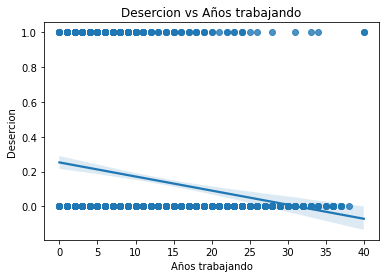

In [ ]:

plt.figure(figsize=(4,4))
fig,ax=plt.subplots() 
sns.regplot(x='TotalWorkingYears',y='AttritionNumber',data=dataFrameCorrelacion)
ax.set_title( "Desercion vs Años trabajando", size=12)
ax.set_ylabel( 'Desercion',size=10)
ax.set_xlabel( 'Años trabajando',size=10)
plt.show()

<Figure size 288x288 with 0 Axes>

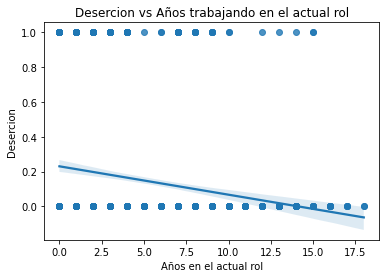

In [ ]:

plt.figure(figsize=(4,4))
fig,ax=plt.subplots() 
sns.regplot(x='YearsInCurrentRole',y='AttritionNumber',data=dataFrameCorrelacion)
ax.set_title( "Desercion vs Años trabajando en el actual rol", size=12)
ax.set_ylabel( 'Desercion',size=10)
ax.set_xlabel( 'Años en el actual rol',size=10)
plt.show()

<Figure size 288x288 with 0 Axes>

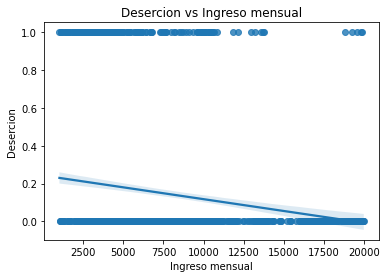

In [ ]:
plt.figure(figsize=(4,4))
fig,ax=plt.subplots() 
sns.regplot(x='MonthlyIncome',y='AttritionNumber',data=dataFrameCorrelacion)
ax.set_title( "Desercion vs Ingreso mensual", size=12)
ax.set_ylabel( 'Desercion',size=10)
ax.set_xlabel( 'Ingreso mensual',size=10)
plt.show()

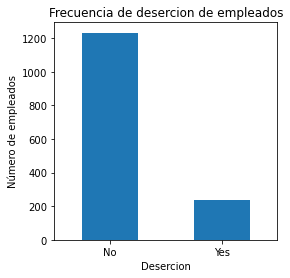

In [ ]:
plt.figure(figsize=(4,4))
count.plot(kind="bar",rot=0)
plt.title("Frecuencia de desercion de empleados")
plt.xlabel("Desercion")
plt.ylabel("Número de empleados")
plt.show()

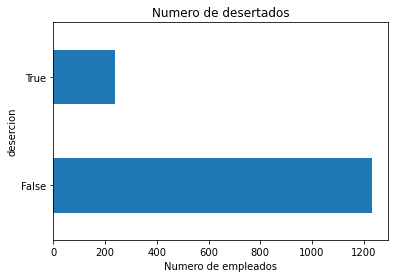

In [ ]:
#dataFrameCorrelacion.sort_values(by='AttritionNumber',inplace=True)
#plt.stackplot(dataFrameCorrelacion.iloc[:,2],dataFrameCorrelacion['AttritionNumber'], labels=['A','B'])
#plt.legend(loc='upper left')
plot=pd.value_counts(dataFrameCorrelacion['AttritionNumber']).plot(kind='barh',title='Numero de desertados',rot=0)
plot.set_ylabel("desercion")
plot.set_xlabel("Numero de empleados")
plt.show()

In [ ]:
#ax = dataFrameCorrelacion.set_index('AttritionNumber').T.plot.bar(stacked=True, rot=0, cmap='tab20', figsize=(10, 7))
#ax.legend(bbox_to_anchor=(1.01, 1.02), loc='upper left')
#plt.tight_layout()
#plt.show()

# Outliers

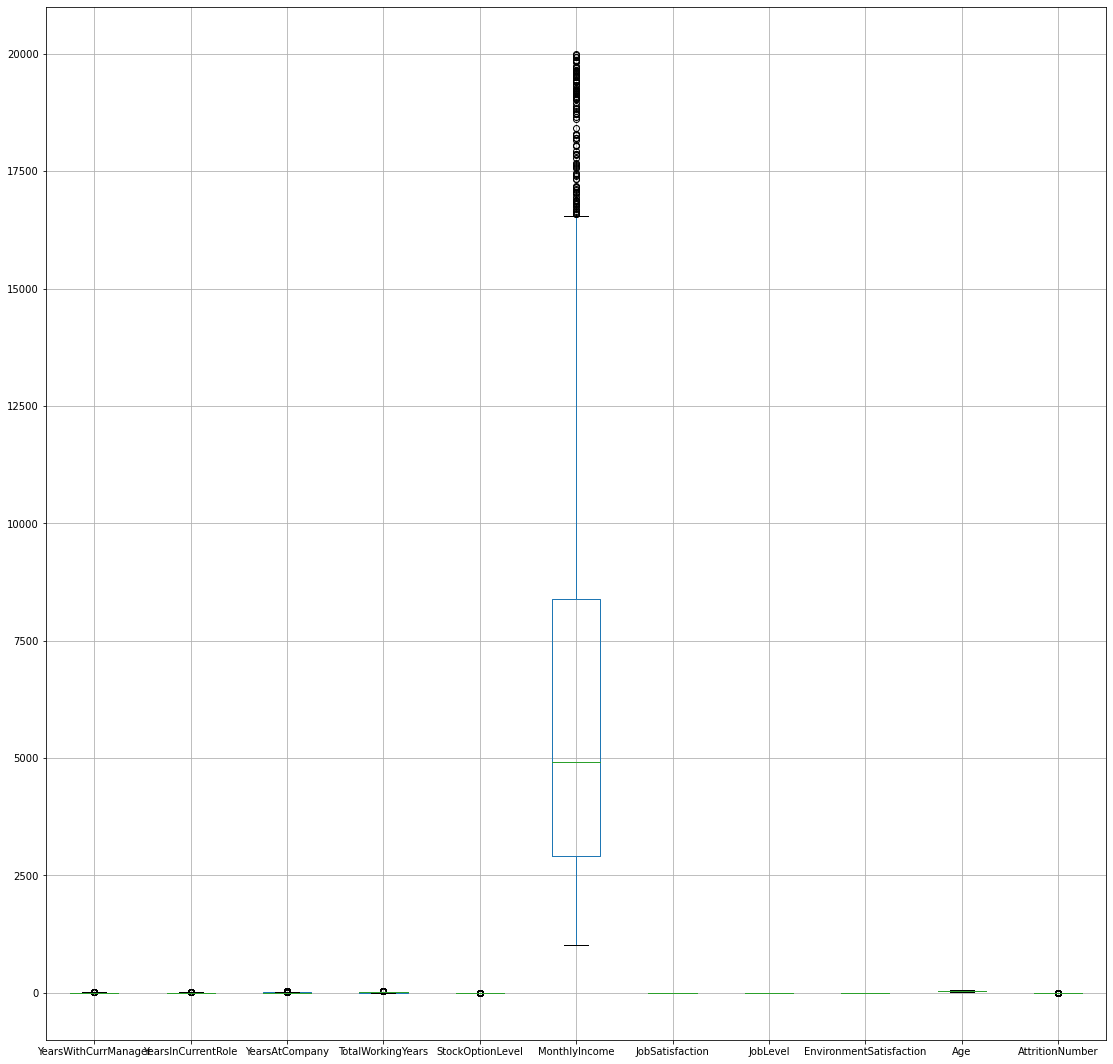

In [ ]:
plt.figure(figsize=(19,19))
dataFrameCorrelacion.boxplot() #identifica todas las variables numéricas
plt.show()

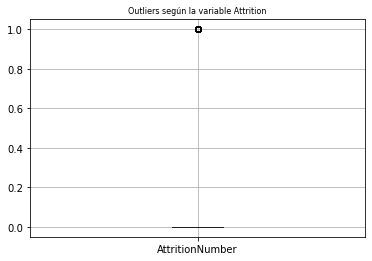

In [ ]:
dataFrameCorrelacion.boxplot('AttritionNumber', figsize = (6,4), color = "blue")
plt.title("Outliers según la variable Attrition" , size=8)
plt.show()

# Discretizacion Uniform



In [ ]:
from sklearn.preprocessing import KBinsDiscretizer 

In [ ]:
disc = KBinsDiscretizer(n_bins=7,encode='ordinal',strategy='uniform')
disc

KBinsDiscretizer(encode='ordinal', n_bins=7, strategy='uniform')

In [ ]:
edad_disc = disc.fit_transform(dataFrameCorrelacion[['Age']])

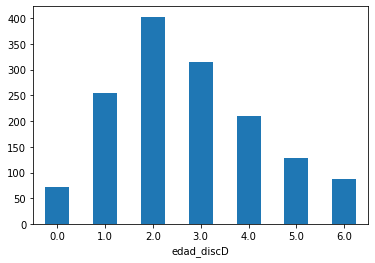

In [ ]:
dfedad = pd.DataFrame(edad_disc,columns=['edad_discD'])
dfedad.groupby("edad_discD").size().plot(kind="bar",rot=0)

In [ ]:
montly_disc = disc.fit_transform(dataFrameCorrelacion[['MonthlyIncome']])

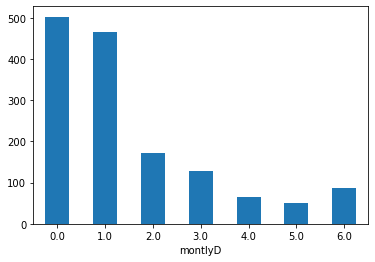

In [ ]:
dfMontly = pd.DataFrame(montly_disc,columns=['montlyD'])
dfMontly.groupby("montlyD").size().plot(kind="bar",rot=0)

# Discretizacion Quantile

In [ ]:
disc2 = KBinsDiscretizer(n_bins=7,encode='ordinal',strategy='quantile')
disc2

KBinsDiscretizer(encode='ordinal', n_bins=7)

In [ ]:
edad_disc2 = disc2.fit_transform(dataFrameCorrelacion[['Age']])

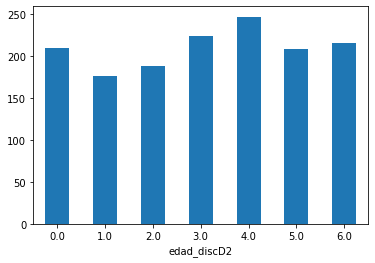

In [ ]:
dfEdad2 = pd.DataFrame(edad_disc2,columns=['edad_discD2'])
dfEdad2.groupby("edad_discD2").size().plot(kind="bar",rot=0)

In [ ]:
montly_disc2 = disc2.fit_transform(dataFrameCorrelacion[['MonthlyIncome']])

In [ ]:
montly_disc2

array([[4.],
       [3.],
       [0.],
       ...,
       [4.],
       [3.],
       [3.]])

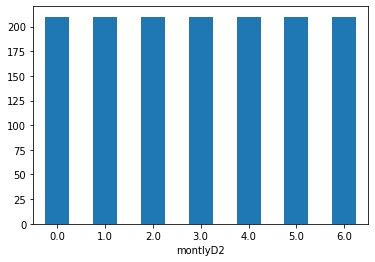

In [ ]:
dfMontly2 = pd.DataFrame(montly_disc2,columns=['montlyD2'])
dfMontly2.groupby("montlyD2").size().plot(kind="bar",rot=0)

# Unión de datos


In [ ]:
dfUnion = pd.concat([dataFrameCorrelacion,dfedad,dfMontly, dfEdad2,dfMontly2],axis=1)
dfUnion

,YearsWithCurrManager,YearsInCurrentRole,YearsAtCompany,TotalWorkingYears,StockOptionLevel,MonthlyIncome,JobSatisfaction,JobLevel,EnvironmentSatisfaction,Age,AttritionNumber,edad_discD,montlyD,edad_discD2,montlyD2
0,5,4,6,8,0,5993,4,2,2,41,True,3.0,1.0,4.0,4.0
1,7,7,10,10,1,5130,2,2,3,49,False,5.0,1.0,6.0,3.0
2,0,0,0,7,0,2090,3,1,4,37,True,3.0,0.0,4.0,0.0
3,0,7,8,8,0,2909,3,1,4,33,False,2.0,0.0,2.0,1.0
4,2,2,2,6,1,3468,2,1,1,27,False,1.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,3,2,5,17,1,2571,4,2,3,36,False,3.0,0.0,3.0,1.0
1466,7,7,7,9,1,9991,1,3,4,39,False,3.0,3.0,4.0,5.0
1467,3,2,6,6,1,6142,2,2,2,27,False,1.0,1.0,0.0,4.0
1468,8,6,9,17,0,5390,2,2,4,49,False,5.0,1.0,6.0,3.0


# Balanceo de datos

In [ ]:
from imblearn.under_sampling import NearMiss

In [ ]:
x = dataFrameCorrelacion.iloc[:,0:10]

In [ ]:
y = dataFrameCorrelacion.iloc[:,10]

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train,y_test= \
                train_test_split(x, 
                     y,
                     test_size=0.3, 
                     random_state=1, 
                     stratify=y)

# Over Sampling

In [ ]:
from imblearn.over_sampling import RandomOverSampler

In [ ]:
os =  RandomOverSampler(sampling_strategy=0.8)

In [ ]:
x_o, y_o = os.fit_resample(x_train, y_train)

In [ ]:
x_over=pd.DataFrame(x_o)

In [ ]:
y_over=pd.DataFrame(y_o)

In [ ]:
df_over=pd.concat([x_over,y_over],axis=1)

In [ ]:
df_over

,YearsWithCurrManager,YearsInCurrentRole,YearsAtCompany,TotalWorkingYears,StockOptionLevel,MonthlyIncome,JobSatisfaction,JobLevel,EnvironmentSatisfaction,Age,AttritionNumber
0,7,6,8,8,2,6549,2,2,3,28,False
1,2,2,2,8,1,6392,1,2,1,33,False
2,10,7,22,22,1,19189,3,5,4,41,False
3,8,8,10,10,2,6799,3,2,2,34,False
4,3,2,4,4,1,3065,1,1,3,31,False
...,...,...,...,...,...,...,...,...,...,...,...
1548,0,2,5,5,1,2307,1,1,4,34,True
1549,0,0,0,5,0,3485,3,1,1,28,True
1550,1,2,2,6,0,2546,2,1,3,29,True
1551,3,2,5,6,0,8224,1,2,1,33,True


# Under Sampling

In [ ]:
underSampling = NearMiss(sampling_strategy=0.8,n_neighbors=5,version=3)

In [ ]:
x_u,y_u= underSampling.fit_resample(x_train,y_train)

In [ ]:
x_under=pd.DataFrame(x_u)

In [ ]:
y_under=pd.DataFrame(y_u)

In [ ]:
df_under=pd.concat([x_under,y_under],axis=1)

In [ ]:
df_under

,YearsWithCurrManager,YearsInCurrentRole,YearsAtCompany,TotalWorkingYears,StockOptionLevel,MonthlyIncome,JobSatisfaction,JobLevel,EnvironmentSatisfaction,Age,AttritionNumber
0,4,4,5,21,0,19926,2,5,3,50,False
1,10,10,29,31,1,19847,2,5,4,51,False
2,7,7,8,25,1,19740,4,5,3,43,False
3,14,6,22,24,0,18880,3,5,1,42,False
4,2,2,3,30,1,18844,4,5,3,59,False
...,...,...,...,...,...,...,...,...,...,...,...
368,0,0,1,12,0,9824,3,3,1,31,True
369,0,0,1,1,0,2693,4,1,4,21,True
370,10,5,23,25,0,12936,3,4,3,47,True
371,2,3,4,6,0,5326,1,2,4,26,True


# Unión datos

In [ ]:
unionUnderOver = pd.concat([dataFrameCorrelacion,df_over,df_under],axis=0)

In [ ]:
unionUnderOver = unionUnderOver.reset_index()

In [ ]:
unionUnderOver = unionUnderOver.drop(columns='index')
unionUnderOver

,YearsWithCurrManager,YearsInCurrentRole,YearsAtCompany,TotalWorkingYears,StockOptionLevel,MonthlyIncome,JobSatisfaction,JobLevel,EnvironmentSatisfaction,Age,AttritionNumber
0,5,4,6,8,0,5993,4,2,2,41,True
1,7,7,10,10,1,5130,2,2,3,49,False
2,0,0,0,7,0,2090,3,1,4,37,True
3,0,7,8,8,0,2909,3,1,4,33,False
4,2,2,2,6,1,3468,2,1,1,27,False
...,...,...,...,...,...,...,...,...,...,...,...
3391,0,0,1,12,0,9824,3,3,1,31,True
3392,0,0,1,1,0,2693,4,1,4,21,True
3393,10,5,23,25,0,12936,3,4,3,47,True
3394,2,3,4,6,0,5326,1,2,4,26,True


In [ ]:
#pip install pyreadstat

# EJERCICIO 2

In [ ]:

df2 = pd.read_spss('/home/david/clasesPython/examen/Examen/data/AusentismoPres2011.sav')

In [ ]:
df2.dtypes

ubigeo                       object
departamento                 object
dom_Geo                      object
provincia                    object
distrito                     object
total_electoral             float64
total_ausentismo            float64
porc_Ausentismo             float64
ord_Ausentismo             category
dic_Ausentismo             category
porc_hogares_sin_medios     float64
IDH                         float64
alfabetismo                 float64
partidoGanador               object
porc_2_NBI                  float64
GINI                        float64
dtype: object

In [ ]:
df2.head(10)


,ubigeo,departamento,dom_Geo,provincia,distrito,total_electoral,total_ausentismo,porc_Ausentismo,ord_Ausentismo,dic_Ausentismo,porc_hogares_sin_medios,IDH,alfabetismo,partidoGanador,porc_2_NBI,GINI
0,010102,Amazonas,Norte,Chachapoyas,Asunción,234.0,59.0,25.213675,Ausentismo Grave,Ausentismo Fuerte,100.00,0.581463,86.893200,PERU POSIBLE,51.11,0.30
1,010103,Amazonas,Norte,Chachapoyas,Balsas,848.0,208.0,24.528301,Ausentismo Grave,Ausentismo Fuerte,94.87,0.562141,86.527290,FUERZA 2011,20.23,0.31
2,010104,Amazonas,Norte,Chachapoyas,Cheto,478.0,51.0,10.669457,Ausentismo Bajo,Ausentismo Leve,99.40,0.599150,92.838196,GANA PERU,16.87,0.28
3,010105,Amazonas,Norte,Chachapoyas,Chiliquín,638.0,197.0,30.877743,Ausentismo Grave,Ausentismo Fuerte,99.60,0.545484,86.541740,FUERZA 2011,31.73,0.29
4,010106,Amazonas,Norte,Chachapoyas,Chuquibamba,1161.0,333.0,28.682170,Ausentismo Grave,Ausentismo Fuerte,99.62,0.584659,92.598430,FUERZA 2011,17.55,0.31
5,010107,Amazonas,Norte,Chachapoyas,Granada,368.0,79.0,21.467392,Ausentismo Fuerte,Ausentismo Fuerte,98.35,0.572618,85.294120,FUERZA 2011,38.84,0.27
6,010108,Amazonas,Norte,Chachapoyas,Huancas,361.0,60.0,16.620499,Ausentismo Moderado,Ausentismo Leve,81.08,0.590812,89.795920,FUERZA 2011,14.41,0.26
7,010109,Amazonas,Norte,Chachapoyas,La Jalca,3066.0,554.0,18.069145,Ausentismo Fuerte,Ausentismo Leve,99.44,0.560589,86.638626,GANA PERU,19.49,0.36
8,010110,Amazonas,Norte,Chachapoyas,Leimebamba,2349.0,566.0,24.095360,Ausentismo Grave,Ausentismo Fuerte,95.78,0.578506,88.742230,PERU POSIBLE,10.85,0.34
9,010111,Amazonas,Norte,Chachapoyas,Levanto,725.0,122.0,16.827587,Ausentismo Moderado,Ausentismo Leve,100.00,0.563036,84.419716,FUERZA 2011,12.26,0.27


In [ ]:
df2.columns

Index(['ubigeo', 'departamento', 'dom_Geo', 'provincia', 'distrito',
       'total_electoral', 'total_ausentismo', 'porc_Ausentismo',
       'ord_Ausentismo', 'dic_Ausentismo', 'porc_hogares_sin_medios', 'IDH',
       'alfabetismo', 'partidoGanador', 'porc_2_NBI', 'GINI'],
      dtype='object')

In [ ]:
df2.corr()

,total_electoral,total_ausentismo,porc_Ausentismo,porc_hogares_sin_medios,IDH,alfabetismo,porc_2_NBI,GINI
total_electoral,1.000000,0.981316,-0.210296,-0.483848,0.407896,0.238776,-0.212214,0.093937
total_ausentismo,0.981316,1.000000,-0.166014,-0.482127,0.400245,0.232167,-0.203127,0.127511
porc_Ausentismo,-0.210296,-0.166014,1.000000,0.507013,-0.332791,-0.187438,0.246162,0.024500
porc_hogares_sin_medios,-0.483848,-0.482127,0.507013,1.000000,-0.782312,-0.555270,0.423876,-0.183802
IDH,0.407896,0.400245,-0.332791,-0.782312,1.000000,0.846161,-0.395977,0.109228
alfabetismo,0.238776,0.232167,-0.187438,-0.555270,0.846161,1.000000,-0.227365,0.059389
porc_2_NBI,-0.212214,-0.203127,0.246162,0.423876,-0.395977,-0.227365,1.000000,-0.090945
GINI,0.093937,0.127511,0.024500,-0.183802,0.109228,0.059389,-0.090945,1.000000


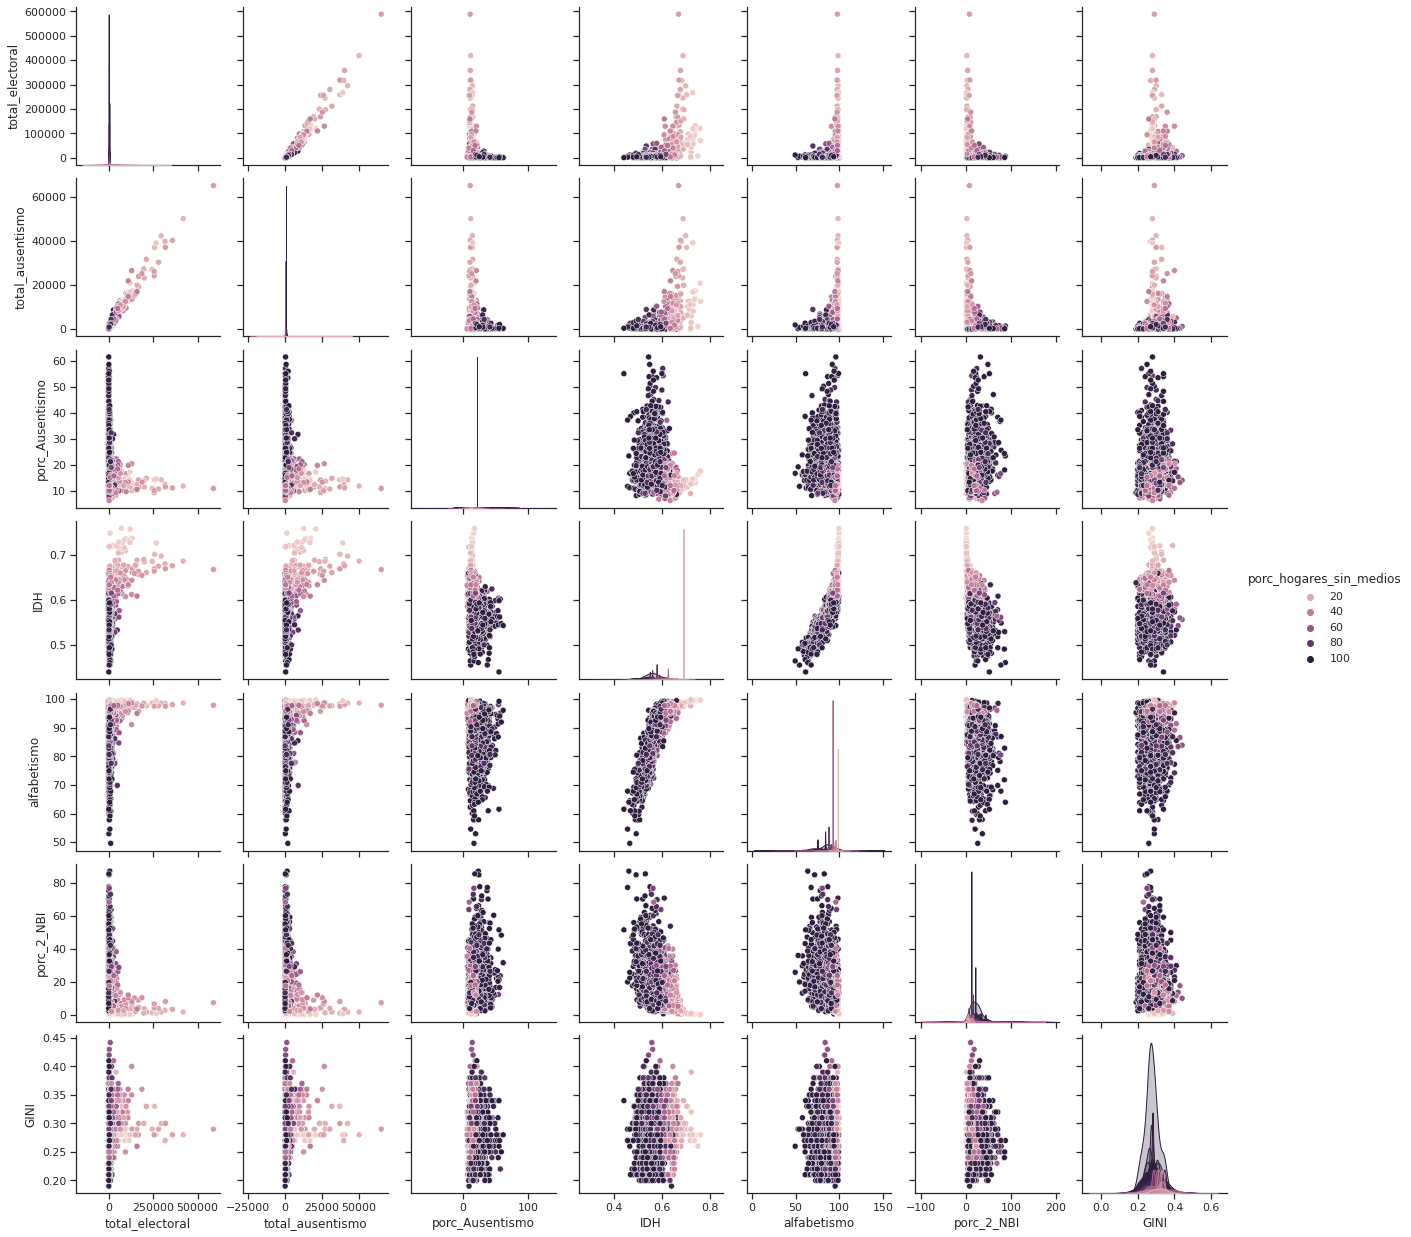

In [ ]:
sns.set_theme(style="ticks")
sns.pairplot(df2, hue="porc_hogares_sin_medios")

In [ ]:
df2.columns

  

Index(['ubigeo', 'departamento', 'dom_Geo', 'provincia', 'distrito',
       'total_electoral', 'total_ausentismo', 'porc_Ausentismo',
       'ord_Ausentismo', 'dic_Ausentismo', 'porc_hogares_sin_medios', 'IDH',
       'alfabetismo', 'partidoGanador', 'porc_2_NBI', 'GINI'],
      dtype='object')

In [ ]:
df2C = df2.iloc[:,[4]]
fit=df2C.apply(lambda x: le[x.name].fit_transform(x))# ajusto, entreno o entiendo lo que necesito
x_train2C=df2C.apply(lambda x: le[x.name].transform(x))#aplico, transformar o predecir 

In [ ]:
x_train2C.head(30)

,distrito
0,93
1,119
2,288
3,302
4,349
5,498
6,559
7,718
8,764
9,767


In [ ]:
from sklearn.model_selection import train_test_split
x= df2.iloc[:,[10,11,12,15]]
y = x_train2C
x_train,x_test,y_train,y_test=train_test_split(x,#valor de predictores
                        y,
                        test_size=0.3,#proporción de datos para datos de test, el complemento datos de entrenamiento
                    
                        random_state=0)#semilla


In [ ]:
import scipy.stats as st
import math as math
n=x_train.shape[0] # número de observaciones
p=x_train.shape[1] # número de variables
n,p

(1283, 4)

In [ ]:
corr_general = x_train.corr()
chi2= round(-(n-1-(2*p+5)/6)*math.log(np.linalg.det(corr_general)),2)
chi2

3019.96

In [ ]:
gl=p*(p-1)/2
gl

6.0

In [ ]:
p_value=st.chi2.pdf(chi2,gl)
p_value

0.0

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [ ]:
x_train_sc=sc.fit_transform(x_train)

In [ ]:
from sklearn.decomposition import PCA
pca=PCA(n_components=4) #indicamos el número de componentes= al # de variables originales.
pca=pca.fit(x_train_sc)

In [ ]:
varianza_explicada= pca.explained_variance_
varianza_explicada

array([2.4988896 , 0.98254806, 0.43244696, 0.0892355 ])

In [ ]:
np.cumsum(pca.explained_variance_ratio_)
#escoger hasta el 80 %

array([0.62423548, 0.86968104, 0.97770851, 1.        ])

In [ ]:
pca1=PCA(n_components=2) #indicamos el número de componentes= al # de variables originales.
pca1=pca1.fit(x_train_sc) #ejecutamos el pca

In [ ]:
pca_cargas_fact= pca1.components_

pca_cargas_fact


array([[-0.54335897,  0.61072012,  0.55466861,  0.15532126],
       [-0.0573922 , -0.11334247, -0.20328617,  0.97084208]])

In [ ]:
pca_scores=pca1.transform(x_train_sc)

In [ ]:
x_train_sc=pd.DataFrame(x_train_sc )

df_pca = pd.DataFrame(pca_scores,columns=["PC1","PC2"])

In [ ]:
x_train_reset= x_train.reset_index(drop=True)
y_train_reset=y_train.reset_index(drop=True)
df_pca_completo= pd.concat([x_train_reset,df_pca,y_train_reset],axis=1)

In [ ]:
df_pca_completo

,porc_hogares_sin_medios,IDH,alfabetismo,GINI,PC1,PC2,distrito
0,98.76,0.570616,90.701805,0.29,-0.173654,-0.104598,1675
1,99.79,0.531697,73.934840,0.25,-1.927535,-0.645419,206
2,99.31,0.498244,67.672806,0.30,-2.552786,0.855417,571
3,72.40,0.553386,86.412700,0.31,-0.006599,0.607381,462
4,17.27,0.688350,98.387990,0.29,3.692632,-0.382777,1212
...,...,...,...,...,...,...,...
1278,99.40,0.557235,88.888885,0.33,-0.317567,0.987271,542
1279,78.57,0.610824,92.692520,0.26,0.815607,-0.966942,943
1280,86.68,0.540231,81.117530,0.22,-1.196630,-1.564097,162
1281,84.06,0.545516,80.053370,0.31,-0.767317,0.745035,1286


In [ ]:
#pip install factor_analyzer

# Analisis factorial

In [ ]:
from factor_analyzer.factor_analyzer import calculate_kmo

In [ ]:
kmo_all,kmo_model=calculate_kmo(x_train)
kmo_model

0.5779074805484733

In [ ]:
kmo_all

array([0.61444238, 0.54554414, 0.58252548, 0.74915695])

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
sc=StandardScaler()

In [ ]:
x_train_sc=sc.fit_transform(x_train)
x_test_sc=sc.fit_transform(x_test)

In [ ]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1283 entries, 943 to 684
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   porc_hogares_sin_medios  1283 non-null   float64
 1   IDH                      1283 non-null   float64
 2   alfabetismo              1283 non-null   float64
 3   GINI                     1283 non-null   float64
dtypes: float64(4)
memory usage: 50.1 KB


In [ ]:
x_train_sc=pd.DataFrame(x_train_sc)

In [ ]:
x_train_sc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1283 entries, 0 to 1282
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       1283 non-null   float64
 1   1       1283 non-null   float64
 2   2       1283 non-null   float64
 3   3       1283 non-null   float64
dtypes: float64(4)
memory usage: 40.2 KB


In [ ]:
from sklearn.decomposition import FactorAnalysis

In [ ]:
fac=FactorAnalysis() #definimos la función - inicializamos la clase
fact_df=fac.fit(x_train_sc)

In [ ]:
fact_df.components_  #cargas factoriales 

array([[-0.75725942,  0.87059541,  0.79142248,  0.16586884],
       [-0.0695474 , -0.0169028 , -0.07078402,  0.24864941],
       [-0.        , -0.        , -0.        , -0.        ],
       [ 0.        ,  0.        , -0.        ,  0.        ]])

In [ ]:

fac10=FactorAnalysis(n_components=4,# de componentes
                    random_state=0) 
fact10=fac10.fit_transform(x_train_sc) #puntuaciones
fact10_df=pd.DataFrame(fact10,columns=["F1","F2","F3","F4"])

In [ ]:
fact10_df.head()

,F1,F2,F3,F4
0,-0.087924,-0.136238,0.0,0.0
1,-1.038506,-0.132353,0.0,0.0
2,-1.490551,0.293676,0.0,0.0
3,-0.068539,0.184362,0.0,0.0
4,2.117586,0.050247,0.0,0.0


In [ ]:
x_train_reset= x_train.reset_index(drop=True)
y_train_reset=y_train.reset_index(drop=True)

df_fact_completo=pd.concat([x_train_reset,fact10_df,y_train_reset],axis=1)

In [ ]:
df_fact_completo.head()

,porc_hogares_sin_medios,IDH,alfabetismo,GINI,F1,F2,F3,F4,distrito
0,98.76,0.570616,90.701805,0.29,-0.087924,-0.136238,0.0,0.0,1675
1,99.79,0.531697,73.934840,0.25,-1.038506,-0.132353,0.0,0.0,206
2,99.31,0.498244,67.672806,0.30,-1.490551,0.293676,0.0,0.0,571
3,72.40,0.553386,86.412700,0.31,-0.068539,0.184362,0.0,0.0,462
4,17.27,0.688350,98.387990,0.29,2.117586,0.050247,0.0,0.0,1212
